# Correlation & Multicollinearity Explorer

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-science-cookbook/correlation-explorer/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-science-cookbook/correlation-explorer/demo.ipynb)

> "Which features relate?" — a correlation heatmap plus VIF to catch the redundant, collinear features that quietly wreck a model.

Correlation tells you which pairs move together. But two features can each look fine pairwise and
still be a problem *together* - that's **multicollinearity**, and it inflates coefficient variance so
your model's weights become nonsense. VIF catches what a correlation matrix misses.

**What this notebook covers**
1. The correlation matrix (pairwise)
2. Why pairwise isn't enough
3. VIF: each feature regressed on all the others
4. Greedy drop suggestions
5. The heatmap, visualized


## Step 1 - Pairwise correlation

Height↔weight, age↔income, weight↔BMI all move together. A good start - but pairwise view can't see
that height, weight, *and* BMI are mutually entangled.

In [1]:
from correxplore import correlation_matrix, high_correlations, vif, suggest_drops, sample_dataframe

df = sample_dataframe()
for p in high_correlations(df, 0.7):
    print(f"  {p.a:<8} ~ {p.b:<8} {p.corr:+.2f}")


  age      ~ income   +0.89
  height   ~ weight   +0.87
  weight   ~ bmi      +0.84


## Step 2 - VIF sees the whole entanglement

`VIF = 1 / (1 - R²)`, where R² is from regressing a feature on *all* the others. BMI is derived from
height and weight, so its VIF explodes even though no single pairwise correlation is 1.0.

In [2]:
v = vif(df)
print(v.to_string(index=False))
print("\nVIF > 10 = serious multicollinearity.")


feature    R2    VIF    flag
 weight 0.992 127.38 serious
 height 0.979  47.67 serious
    bmi 0.975  40.76 serious
    age 0.788   4.71      ok
 income 0.788   4.71      ok

VIF > 10 = serious multicollinearity.


## Step 3 - What to drop

Blindly dropping all high-VIF features is wrong (they're collinear *with each other*). The greedy
fix: drop the single worst, recompute, repeat - removing the minimum needed.

In [3]:
drops = suggest_drops(df)
print("Suggested drops:", drops)
kept = [c for c in df.select_dtypes("number").columns if c not in drops]
print("Kept features:", kept)
print("\nVIF after dropping:")
print(vif(df.drop(columns=drops)).to_string(index=False))


Suggested drops: ['weight']
Kept features: ['height', 'bmi', 'age', 'income']

VIF after dropping:
feature    R2  VIF flag
    age 0.788 4.71   ok
 income 0.787 4.70   ok
 height 0.225 1.29   ok
    bmi 0.226 1.29   ok


## Step 4 - The heatmap

The at-a-glance view: red = strong positive, blue = strong negative. The height/weight/BMI block
lights up as one hot cluster - exactly what VIF quantified.

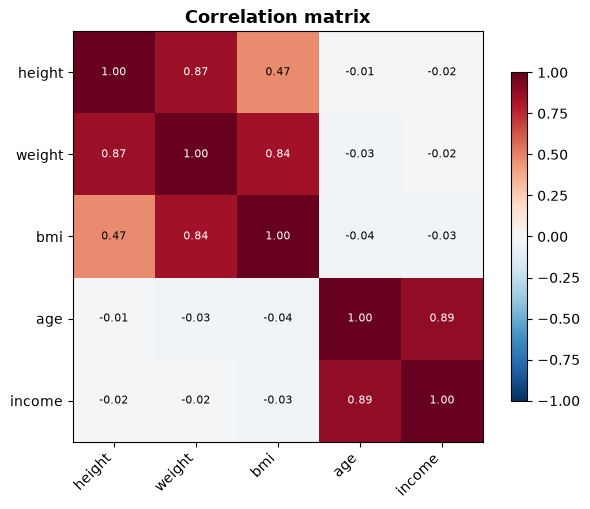

In [4]:
import matplotlib.pyplot as plt

corr = correlation_matrix(df)
fig, ax = plt.subplots(figsize=(6.5, 5.2))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.values[i,j]:.2f}", ha="center", va="center", fontsize=8,
                color="white" if abs(corr.values[i,j]) > 0.5 else "black")
ax.set_title("Correlation matrix", fontsize=13, weight="bold")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.savefig("corr_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()


## Summary

| Feature | VIF | Verdict |
|---------|-----|---------|
| weight | 127 | drop (derived cluster) |
| height | 48 | collinear |
| bmi | 41 | collinear |
| age / income | ~5 | borderline, keep |

Correlation is the first look; **VIF is the honest one** for modeling. Drop redundant features before
fitting a regression and the surviving coefficients become interpretable again.

**Extend it:** add partial correlations, condition-number diagnostics, and an option to keep the most
*business-meaningful* feature in each collinear cluster rather than the lowest-VIF one.

In [5]:
# --- Try your own data ---
# import pandas as pd
# my_df = pd.read_csv("your_data.csv")
# print(vif(my_df))
# print("drop:", suggest_drops(my_df))


---

Part of [**phoebe-the-builder**](https://github.com/phoebefu6/phoebe-the-builder) - Day 112,
Month 12: Data Science Cookbook.

**Run the app:** `pip install -r requirements.txt && streamlit run app.py`